In [1]:
# ============================================================
# COLAB SETUP — Copy this as the first cell every session
# University of Pittsburgh | Biochar Feedstock Methodology
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL — lost every session, must reinstall
# ------------------------------------------------------------
!pip install -q earthengine-api geemap

# ------------------------------------------------------------
# 2. MOUNT GOOGLE DRIVE — access your files
# ------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')


# Define your project folder path — change once if needed
PROJECT_FOLDER = '/content/drive/MyDrive/BiocharProject/'

# ------------------------------------------------------------
# 3. IMPORT LIBRARIES
# ------------------------------------------------------------
import ee                            # Google Earth Engine
import geemap                        # Interactive maps
import pandas as pd                  # CSV and data tables
import matplotlib.pyplot as plt      # Charts and figures
import os                            # File and folder operations
os.environ['GOOGLE_MAPS_API_KEY'] = ''  # Prevents Colab timeout error
from IPython.display import display # Import display for explicit rendering


# ------------------------------------------------------------
# 4. CONNECT TO GEE
# ------------------------------------------------------------
ee.Authenticate()  # ← uncomment ONLY if token expired
ee.Initialize(project='spry-blade-487218-n0')

# ------------------------------------------------------------
# 5. CONFIRM EVERYTHING IS READY
# ------------------------------------------------------------
print('✅ Libraries imported')
print('✅ Google Drive mounted')
print('✅ GEE connected')
print(f'✅ Project folder: {PROJECT_FOLDER}')
print('\nReady to work!')

✅ Libraries imported
✅ Google Drive mounted
✅ GEE connected
✅ Project folder: /content/drive/MyDrive/BiocharProject/

Ready to work!


first of all it is important to connect to the google drive to access the data and also to the pronect that I ceated.

second it is important to import the libraries that I need to use espaically on collab since it's not stored on colab.

third it is important to connect to the google earth engine to access the data and also to the pronect that I ceated 

when it's done print a message to confirm that everything is ready




In [2]:
# ------------------------------------------------------------
# STEP 1 — Load the datasets and inspect them
# ------------------------------------------------------------
Hansen_GFC_2024 = ee.Image("UMD/hansen/global_forest_change_2024_v1_12")

GLC_FSC30D_annual    = ee.ImageCollection('projects/sat-io/open-datasets/GLC-FCS30D/annual');

GLC_FSC30D_five_year = ee.ImageCollection('projects/sat-io/open-datasets/GLC-FCS30D/five-years-map');

#print('Hansen Global Forest Change 2024:', Hansen_GFC_2024.bandNames().getInfo())
#print('Annual collection info:', GLC_FSC30D_annual.first().bandNames().getInfo()); # Fixed: Access bandNames from the first image in the collection
#print('Five-year collection info:', GLC_FSC30D_five_year.first());
#print('Number of annual tiles:', GLC_FSC30D_five_year.size().getInfo()); # Fixed: Removed bandNames() call on ee.Number

# ============================================================
# STEP 2 — Select bands for HANSEN
# ============================================================
treecover2000 = Hansen_GFC_2024.select('treecover2000')
datamask = Hansen_GFC_2024.select('datamask')

# ============================================================
# STEP 3 — Mask the layers
# ============================================================
treecover2000_masked = treecover2000.updateMask(treecover2000.gt(0)).updateMask(datamask.eq(1))

glc_2000 = GLC_FSC30D_annual.mosaic().select('b1');

#print('GLC_FCS30D 2000 — band info:', glc_2000.bandNames().getInfo())
# ============================================================

#  VISUALIZE GLC_FSC30D — using official class colors
# ============================================================

#Class values and their official colors from the dataset
classValues = [
    10, 11, 12, 20, 51, 52, 61, 62, 71, 72,
  81, 82, 91, 92, 120, 121, 122, 130, 140,
  150, 152, 153, 181, 182, 183, 184, 185,
  186, 187, 190, 200, 201, 202, 210, 220, 0
              ]
palette_GLC_FSC30D = [
  'ffff64', 'ffff64', 'ffff00', 'aaf0f0',
  '4c7300', '006400', 'a8c800', '00a000',
  '005000', '003c00', '286400', '285000',
  'a0b432', '788200', '966400', '964b00',
  '966400', 'ffb432', 'ffdcd2', 'ffebaf',
  'ffd278', 'ffebaf', '00a884', '73ffdf',
  '9ebb3b', '828282', 'f57ab6', '66cdab',
  '444f89', 'c31400', 'fff5d7', 'dcdcdc',
  'fff5d7', '0046c8', 'ffffff', 'ffffff'
                ]

forestClasses = [

  {'code': 51,  'color': '4c7300', 'name': '51 Open evergreen broadleaved'},
  {'code': 52,  'color': '006400', 'name': '52 Closed evergreen broadleaved'},
  {'code': 61,  'color': 'a8c800', 'name': '61 Open deciduous broadleaved'},
  {'code': 62,  'color': '00a000', 'name': '62 Closed deciduous broadleaved'},
  {'code': 71,  'color': '005000', 'name': '71 Open evergreen needleleaved'},
  {'code': 72,  'color': '003c00', 'name': '72 Closed evergreen needleleaved'},
  {'code': 81,  'color': '286400', 'name': '81 Open deciduous needleleaved'},
  {'code': 82,  'color': '285000', 'name': '82 Closed deciduous needleleaved'},
  {'code': 91,  'color': 'a0b432', 'name': '91 Open mixed forest'},
  {'code': 92,  'color': '788200', 'name': '92 Closed mixed forest'},

  ]#

glc_2000_vis = glc_2000.remap(classValues,ee.List.sequence(1, len(classValues)))
#print('GLC_FCS30D 2000 — band info:', glc_2000_vis.)

glc_2000_filtered = glc_2000_vis.updateMask(glc_2000_vis.lt(34)) # to visualize the land cover without Water body, Permanent ice and snow and Filled value
glc_forest = glc_2000.gte(51).And(glc_2000.lte(92)).selfMask() # forest mask 

#print('Debugging glc_forest mask:')
#print('Band names:', glc_forest.bandNames().getInfo())

earth_map = geemap.Map()
#earth_map.addLayer(treecover2000_masked.updateMask(treecover2000.gte(20)), {'min': 0, 'max': 1, 'palette': ['5F9EA0']}, 'Hansen GFC tree cover 2000 ')
# the threshold is very important for the Hansen tree cover since the forst defintion is not fixed yet

#determine th total forest are with 2 definitions of >= 10 & 30%
treecover2000_masked_forest_gte_10_pt = treecover2000_masked.updateMask(treecover2000_masked.gte(10))
treecover2000_masked_forest_gte_30_pt = treecover2000_masked.updateMask(treecover2000_masked.gte(30))

earth_map.addLayer(treecover2000_masked_forest_gte_10_pt, {'min': 0, 'max': 1, 'palette': ['#006241']}, 'Hansen GFC tree cover 2000 >= 10%')
earth_map.addLayer(treecover2000_masked_forest_gte_30_pt, {'min': 0, 'max': 1, 'palette': ['#006400']}, 'Hansen GFC tree cover 2000 >= 30%')

#earth_map.addLayer( glc_2000_filtered,  {'min': 1, 'max': 34, 'palette': palette_GLC_FSC30D[1:34]},  'GLC_FCS30D 2000');
# Explicitly display the map but removed "Water body", "Permanent ice and snow", "Filled value

for fc in forestClasses:
        class_layer = glc_2000.eq(fc['code']).selfMask() # Corrected gls_forest to glc_forest
        earth_map.addLayer(
            class_layer,
            {'min': 0, 'max': 1, 'palette': [fc['color']]},
            f"GLC {fc['name']}"
        )
#earth_map.addLayer(glc_forest,{'min': 0, 'max': 1, 'palette': ['green']}, 'GLC Forest Mask 2000')

#display(earth_map)

TimeoutException: Requesting secret GOOGLE_MAPS_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

It's normal to not work on antigravity since secret GOOGLE_MAPS_API_KEY can only be fetched when running from the coal UI
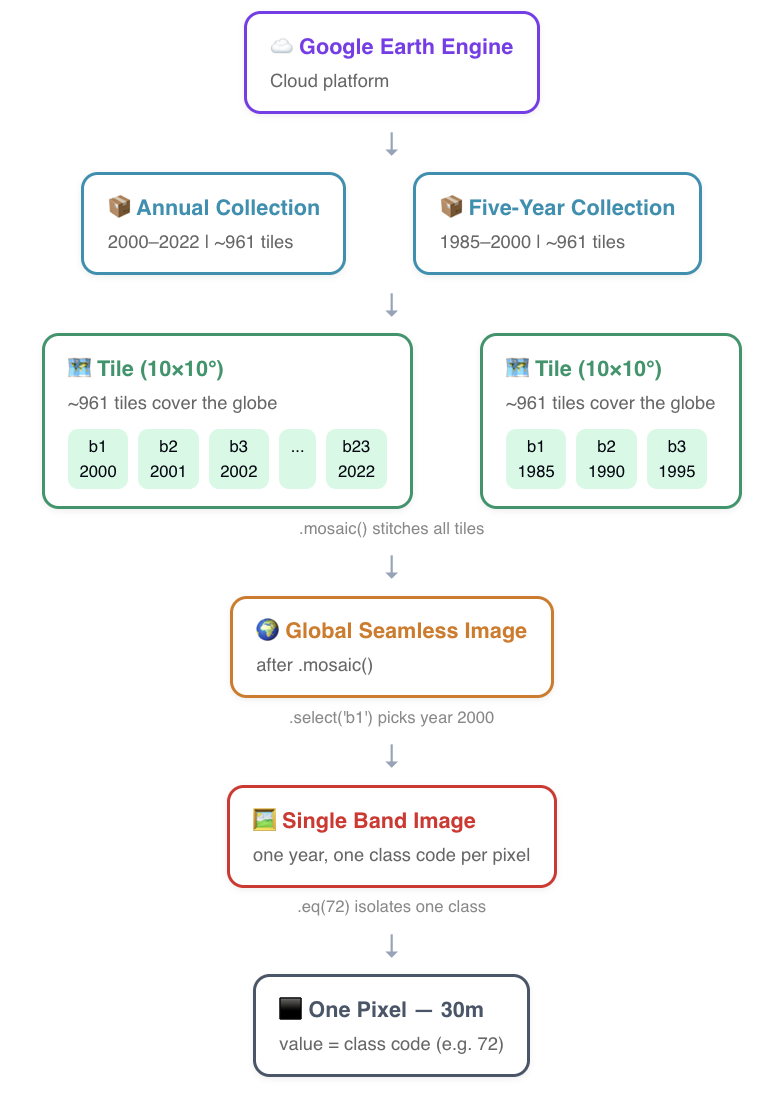{scale=0.6}


In [4]:
# define the canopy cover ranges and thresholds to exploit the treecover 2000 and to asses the composiiton of the each type of forest from GLC SC30D
tree_canopy_threshold = []
tree_canopy_range_list = []
i =10
while i < 101:
    tree_canopy_threshold.append(i)
    j= i+10

    tree_canopy_range_list.append({'range': f'{i}-{j}%'})
    i = i + 10

print(tree_canopy_threshold)
print(tree_canopy_range_list)

# create lists for the main world regions and subregions for forests as well as the main countries for roundwood prodcution (data from FAO)
world_region_list = {
    'Asia' : ['East Asia', 'Western and Southern Asia', 'Central Asia', 'South Asia', 'Southeast Asia'],
    'Europe' : ['Eastern Europe', 'Western Europe', 'Northern Europe', 'Southern Europe'],
    'Africa' : ['Eastern Africa', 'Western Africa', 'Northern Africa', 'Southern Africa'],
    'Americas': ['North America', 'Central America', 'South America'],
    'Oceania': ['Australia and New Zealand', 'Pacific Islands']
}

print(world_region_list)

# loop through all regions and their subregions
#for region, subregions in world_region_list.items():
 #   print(f'{region} - {subregions}')

wood_producing_countries = {
    'Asia': ['China', 'India', 'Indonesia', 'Japan'],
    'Europe': ['Russia', 'Sweeden', 'Germany', 'Italy', 'Spain', 'France'],
    'Africa': ['Nigeria', 'Egypt', 'Kenya', 'Tanzania','South Africa', 'Ethiopia', 'Democratic Republic of the Congo'],
    'Americas': ['Brazil', 'United States', 'Canada'],
    'Oceania': ['Australia', 'New Zealand']
}



#loop through the regions and the main countires

#for region, countries in wood_producing_countries.items():
 #   print(f'{region} - {countries}')


# FAO Regional Distribution of Countries
# Source: FAO - The Second Report on the State of the World's PGRFA, Annex 2
#https://www.fao.org/4/i1500e/i1500e10.pdf

FAO_LSIB_REGION = {
    "Africa": {
        "Central Africa": [
            "Cameroon", "Central African Rep", "Dem Rep of the Congo",
            "Rep of the Congo", "Equatorial Guinea", "Gabon", "Sao Tome & Principe"
        ],
        "East Africa": [
            "Burundi", "Djibouti", "Eritrea", "Ethiopia", "Kenya", "Rwanda",
            "Somalia", "Sudan", "Uganda"
        ],
        "Indian Ocean Islands": [
            "Comoros", "Madagascar", "Mauritius", "Seychelles"
        ],
        "Southern Africa": [
            "Angola", "Botswana", "Lesotho", "Malawi", "Mozambique", "Namibia",
            "South Africa", "Swaziland", "Tanzania", "Zambia", "Zimbabwe"
        ],
        "West Africa": [
            "Benin", "Burkina Faso", "Cabo Verde", "Chad", "Cote d'Ivoire", "Gambia, The",
            "Ghana", "Guinea", "Guinea-Bissau", "Liberia", "Mali", "Mauritania",
            "Niger", "Nigeria", "Senegal", "Sierra Leone", "Togo"
        ],
    },
    "Americas": {
        "Caribbean": [
            "Antigua & Barbuda", "Bahamas, The", "Barbados", "Belize", "Cuba", "Dominica",
            "Dominican Republic", "Grenada", "Guyana", "Haiti", "Jamaica",
            "St Kitts & Nevis", "Saint Lucia", "St Vincent & the Grenadines",
            "Suriname", "Trinidad & Tobago"
        ],
        "Central America and Mexico": [
            "Costa Rica", "El Salvador", "Guatemala", "Honduras", "Mexico",
            "Nicaragua", "Panama"
        ],
        "North America": [
            "Canada", "United States"
        ],
        "South America": [
            "Argentina", "Bolivia", "Brazil", "Chile",
            "Colombia", "Ecuador", "Paraguay", "Peru", "Uruguay",
            "Venezuela"
        ],
    },
    "Europe": {
        "Eastern Europe": [
            "Albania", "Armenia", "Belarus", "Bosnia & Herzegovina", "Bulgaria",
            "Croatia", "Czechia", "Estonia", "Georgia", "Hungary", "Latvia",
            "Lithuania", "Montenegro", "Poland", "Moldova", "Romania",
            "Russia", "Serbia", "Slovakia", "Slovenia",
            "Macedonia", "Ukraine"
        ],
        "Western Europe": [
            "Andorra", "Austria", "Belgium", "Denmark", "Finland", "France",
            "Germany", "Greece", "Iceland", "Ireland", "Italy", "Liechtenstein",
            "Luxembourg", "Monaco", "Netherlands", "Norway", "Portugal",
            "San Marino", "Spain", "Sweden", "Switzerland", "United Kingdom"
        ],
    },
    "Near East": {
        "Central Asia": [
            "Azerbaijan", "Kazakhstan", "Kyrgyzstan", "Tajikistan",
            "Turkmenistan", "Uzbekistan"
        ],
        "South/East Mediterranean": [
            "Algeria", "Cyprus", "Egypt", "Israel", "Jordan", "Lebanon",
            "Libya", "Malta", "Morocco", "Syria",
            "Tunisia", "West Bank"
        ],
        "West Asia": [
            "Afghanistan", "Bahrain", "Iran", "Iraq", "Kuwait",
            "Oman", "Pakistan", "Qatar", "Saudi Arabia", "Turkey",
            "United Arab Emirates", "Yemen"
        ],
    },
    "Asia and the Pacific": {
        "East Asia": [
            "China", "Korea, North", "Japan",
            "Mongolia", "Korea, South"
        ],
        "Pacific Region": [
            "Australia", "Cook Is", "Fiji", "Kiribati", "Marshall Is",
            "Fed States of Micronesia", "Nauru", "New Zealand", "Niue",
            "Palau", "Papua New Guinea", "Samoa", "Solomon Is",
            "Tonga", "Tuvalu", "Vanuatu"
        ],
        "South Asia": [
            "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Sri Lanka"
        ],
        "Southeast Asia": [
            "Brunei", "Cambodia", "Indonesia",
            "Laos", "Malaysia", "Burma",
            "Philippines", "Singapore", "Thailand", "Timor-Leste", "Vietnam"
        ],
    },
}

# ── Helper: flat list of all countries ───────────────────────────────────────
def get_all_countries(regions):
    countries = []
    for region in regions.values():
        for subregion_countries in region.values():
            countries.extend(subregion_countries)
    return sorted(countries)


# ── Helper: country → region/subregion lookup dict ───────────────────────────
def build_country_lookup(regions):
    lookup = {}
    for region_name, subregions in regions.items():
        for subregion_name, countries in subregions.items():
            for country in countries:
                lookup[country] = {
                    "region": region_name,
                    "subregion": subregion_name
                }
    return lookup

get_all_countries(FAO_LSIB_REGION)
build_country_lookup(FAO_LSIB_REGION)

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
[{'range': '10-20%'}, {'range': '20-30%'}, {'range': '30-40%'}, {'range': '40-50%'}, {'range': '50-60%'}, {'range': '60-70%'}, {'range': '70-80%'}, {'range': '80-90%'}, {'range': '90-100%'}, {'range': '100-110%'}]
{'Asia': ['East Asia', 'Western and Southern Asia', 'Central Asia', 'South Asia', 'Southeast Asia'], 'Europe': ['Eastern Europe', 'Western Europe', 'Northern Europe', 'Southern Europe'], 'Africa': ['Eastern Africa', 'Western Africa', 'Northern Africa', 'Southern Africa'], 'Americas': ['North America', 'Central America', 'South America'], 'Oceania': ['Australia and New Zealand', 'Pacific Islands']}


{'Cameroon': {'region': 'Africa', 'subregion': 'Central Africa'},
 'Central African Rep': {'region': 'Africa', 'subregion': 'Central Africa'},
 'Dem Rep of the Congo': {'region': 'Africa', 'subregion': 'Central Africa'},
 'Rep of the Congo': {'region': 'Africa', 'subregion': 'Central Africa'},
 'Equatorial Guinea': {'region': 'Africa', 'subregion': 'Central Africa'},
 'Gabon': {'region': 'Africa', 'subregion': 'Central Africa'},
 'Sao Tome & Principe': {'region': 'Africa', 'subregion': 'Central Africa'},
 'Burundi': {'region': 'Africa', 'subregion': 'East Africa'},
 'Djibouti': {'region': 'Africa', 'subregion': 'East Africa'},
 'Eritrea': {'region': 'Africa', 'subregion': 'East Africa'},
 'Ethiopia': {'region': 'Africa', 'subregion': 'East Africa'},
 'Kenya': {'region': 'Africa', 'subregion': 'East Africa'},
 'Rwanda': {'region': 'Africa', 'subregion': 'East Africa'},
 'Somalia': {'region': 'Africa', 'subregion': 'East Africa'},
 'Sudan': {'region': 'Africa', 'subregion': 'East Africa'

In [5]:
# ── Helper: flat list of all countries ───────────────────────────────────────
def get_all_countries(regions):
    countries = []
    for region in regions.values():
        for subregion_countries in region.values():
            countries.extend(subregion_countries)
    return sorted(countries)


# ── Helper: country → region/subregion lookup dict ───────────────────────────
def build_country_lookup(regions):
    lookup = {}
    for region_name, subregions in regions.items():
        for subregion_name, countries in subregions.items():
            for country in countries:
                lookup[country] = {
                    "region": region_name,
                    "subregion": subregion_name
                }
    return lookup

test_region = {"Americas": {"North America": FAO_LSIB_REGION["Americas"]["North America"]}
}
test_countries=get_all_countries(test_region)
print(test_countries)
# ── Main function ─────────────────────────────────────────────────────────────
# ── Function 1: prepare GEE FeatureCollection for one threshold ───────────────
def prepare_forest_collection(selected_regions, threshold):

    # 1. Flat list of FAO country names
    all_countries = get_all_countries(selected_regions)

    # 2. Build country lookup — add region/subregion as GEE properties
    country_lookup = build_country_lookup(selected_regions)

    # 3. Filter LSIB to FAO countries only
    lsib_fao = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
                 .filter(ee.Filter.inList('country_na', all_countries))

    # 4. Apply forest mask for this threshold
    forest_mask = treecover2000_masked.gte(threshold).selfMask()

    # 5. Convert to area in Mha
    area_image = forest_mask.multiply(ee.Image.pixelArea().divide(1e10))

    # 6. reduceRegions — no .getInfo(), returns GEE object
    region_areas = area_image.reduceRegions(
        collection=lsib_fao,
        reducer=ee.Reducer.sum(),
        scale=30,
      )

    # 7. Add threshold as a property to each feature
    region_areas = region_areas.map(
        lambda add_threshold: add_threshold.set('threshold', threshold)
    )

    return region_areas  # ← GEE FeatureCollection, not yet computed


# ── Function 2: export one threshold to Google Drive ─────────────────────────
def export_forest_area(selected_regions, thresholds):

    tasks = []

    for threshold in thresholds:

        # prepare the GEE collection
        fc = prepare_forest_collection(selected_regions, threshold)

        # submit export task to Google Drive
        task = ee.batch.Export.table.toDrive(
            collection=fc,
            description=f'forest_area_{threshold}',   # task name in GEE
            folder='GEE_exports',                      # folder in your Google Drive
            fileNamePrefix=f'forest_area_{threshold}', # CSV filename
            fileFormat='CSV',
            selectors=['country_na', 'threshold', 'sum']  # columns to export
        )
        task.start()
        tasks.append(task)
        print(f"Task submitted for threshold {threshold}%")

    return tasks


# ── Run ───────────────────────────────────────────────────────────────────────
tasks = export_forest_area(FAO_LSIB_REGION, [10, 30])

# ── Monitor task status ───────────────────────────────────────────────────────
for task in tasks:
    print(task.status())



['Canada', 'United States']
Task submitted for threshold 10%
Task submitted for threshold 30%
{'state': 'READY', 'description': 'forest_area_10', 'priority': 100, 'creation_timestamp_ms': 1774296783964, 'update_timestamp_ms': 1774296783964, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'AX6U2ERJOPTQDPGCBADZGRW2', 'name': 'projects/spry-blade-487218-n0/operations/AX6U2ERJOPTQDPGCBADZGRW2'}
{'state': 'READY', 'description': 'forest_area_30', 'priority': 100, 'creation_timestamp_ms': 1774296784215, 'update_timestamp_ms': 1774296784215, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'D4GGQYMDLVYMZZZ22XI4KSM7', 'name': 'projects/spry-blade-487218-n0/operations/D4GGQYMDLVYMZZZ22XI4KSM7'}


In [34]:
  for task in tasks:
    status = task.status()
    print(f"{status['description']}: {status['state']}")

  df_10 = pd.read_csv('/content/drive/MyDrive/BiocharProject/GEE_exports/forest_area_10.csv')
  df_30 = pd.read_csv('/content/drive/MyDrive/BiocharProject/GEE_exports/forest_area_30.csv')

df=pd.concat([df_10, df_30], ignore_index = True)
df = df.groupby(['country_na', 'threshold'])['sum'].sum().reset_index()

# 1. Generate the lookup dictionary
country_lookup = build_country_lookup(FAO_LSIB_REGION)
# 2. Create the new columns by looking up each country name
# we could actualy transform the country_lookup from a dictionary to a data frame then merge with df bsed onthe country name

df['region'] = df['country_na'].map(lambda c: country_lookup.get(c, {}).get('region', 'unknown'))
df['subregion'] = df['country_na'].map(lambda c: country_lookup.get(c, {}).get('subregion', 'unknown'))

# rename columns
df.rename(columns={'country_na': 'country', 'sum': 'area_Mha'}, inplace=True)
df.to_csv('/content/drive/MyDrive/BiocharProject/GEE_exports/forest_area_final.csv', index=False)
#print(df_10.head(100))
#print(df_30.head())
#print(df.head())

df_subregion = df.groupby(['subregion', 'threshold'])['area_Mha'].sum().reset_index()
df_region = df.groupby(['region', 'threshold'])['area_Mha'].sum().reset_index()
print(df_subregion)
print(df_region)
print(df.groupby('threshold')['area_Mha'].sum().reset_index())

forest_area_10: COMPLETED
forest_area_30: COMPLETED
                     subregion  threshold    area_Mha
0                    Caribbean         10   44.914979
1                    Caribbean         30   43.805069
2               Central Africa         10  391.683935
3               Central Africa         30  331.515458
4   Central America and Mexico         10  100.311407
5   Central America and Mexico         30   87.390996
6                 Central Asia         10    8.958732
7                 Central Asia         30    6.363492
8                  East Africa         10   72.352689
9                  East Africa         30   24.260580
10                   East Asia         10  235.291287
11                   East Asia         30  204.259002
12              Eastern Europe         10  966.856248
13              Eastern Europe         30  835.482441
14        Indian Ocean Islands         10   33.673654
15        Indian Ocean Islands         30   17.324092
16               North America

forest are is calculate now per country, let's now now try to group the are per region and subregion 

In [ ]:


forest_area_FAO = pd.read_csv('/content/drive/MyDrive/BiocharProject/FAO_data/fao_forest_area_country.csv', header=1)
forest_area_FAO.rename(columns={'Unnamed: 0': 'country'}, inplace=True)

FAO_name_fix = {
    'Democratic Republic of the Congo':          'Dem Rep of the Congo',
    'Congo':                                     'Rep of the Congo',
    'Iran (Islamic Republic of)':                'Iran',
    'Syrian Arab Republic':                      'Syria',
    "Lao People's Democratic Republic":          'Laos',
    'Democratic People\'s Republic of Korea':    'Korea, North',
    'Republic of Korea':                         'Korea, South',
    'Viet Nam':                                  'Vietnam',
    'Myanmar':                                   'Burma',
    'Türkiye':                                   'Turkey',
    'Brunei Darussalam':                         'Brunei',
    'United Republic of Tanzania':               'Tanzania',
    'United States of America':                  'United States',
    'Eswatini':                                  'Swaziland',
    "Côte d'Ivoire":                             "Cote d'Ivoire",
    'Gambia':                                    'Gambia, The',
    'Bahamas':                                   'Bahamas, The',
    'Sao Tome and Principe':                     'Sao Tome & Principe',
    'Antigua and Barbuda':                       'Antigua & Barbuda',
    'Saint Kitts and Nevis':                     'St Kitts & Nevis',
    'Saint Vincent and the Grenadines':          'St Vincent & the Grenadines',
    'Trinidad and Tobago':                       'Trinidad & Tobago',
    'Central African Republic':                  'Central African Rep',
    'Palestine':                                 'West Bank',
    'Bosnia and Herzegovina':                    'Bosnia & Herzegovina',
    'Russian Federation':                        'Russia',
    'Bolivia (Plurinational State of)':          'Bolivia',
    'Venezuela (Bolivarian Republic of)':        'Venezuela',
    'Cabo Verde':                                'Cabo Verde',
}

forest_area_FAO['country']=forest_area_FAO['country'].replace(FAO_name_fix)
print(forest_area_FAO.head())
print(forest_area_FAO.columns.tolist())

fao_countries = set(forest_area_FAO['country'])
lsib_countries=set(get_all_countries(FAO_LSIB_REGION))
print(fao_countries - lsib_countries)
print(lsib_countries -fao_countries )

       country      1990      2000      2010      2015      2020      2025
0  Afghanistan   1209.44   1209.44   1209.44   1209.44   1209.44   1209.44
1      Albania    788.80    769.30    782.07    797.18    941.00    941.00
2      Algeria   1714.96   1708.22   1701.47   1698.10   1694.73   1691.36
3      Andorra     17.69     17.29     18.08     18.29     18.16     18.22
4       Angola  77533.29  76013.08  70912.78  68362.63  65812.48  63262.33
['country', '1990', '2000', '2010', '2015', '2020', '2025']
{'Saint Barthélemy', 'British Virgin Islands', 'Bermuda', 'Turks and Caicos Islands', 'Saint Martin (French Part)', 'Ascension, Saint Helena and Tristan da Cunha', 'Guadeloupe', 'Western Sahara', 'South Sudan', 'Greenland', 'Montserrat', 'Cayman Islands', 'Bonaire, Sint Eustatius and Saba', 'Puerto Rico', 'Réunion', 'Anguilla', 'Saint Pierre and Miquelon', 'Curaçao', 'Aruba', 'Sint Maarten (Dutch part)', '© FRA 2026', 'Martinique', 'United States Virgin Islands', 'Mayotte'}
{'Tuvalu', 